In [39]:
### load tree
from treeswift import read_tree_newick
tree_file = "../figure_3a/ssdna_normscores.nwk"
tree = read_tree_newick(tree_file)
print(tree.diameter())

1.1921081720000002


In [40]:
### map seq_names to nodes
map_all = tree.label_to_node(selection='all')

In [41]:
import polars as pl
ssdna_viruses = pl.read_csv('../ssdna_annotations/all_ssdna_annotations.tsv', separator='\t')

In [42]:
### % of ssDNA genomes that are complete
import polars as pl
print(
    ssdna_viruses
        .filter(pl.col('checkv_quality') == 'Complete').height / ssdna_viruses.height
)

0.6014605203103606


In [43]:
### % of faserviricetes v non-faserviricetes genomes that are complete
import polars as pl
print("Prop Faserviricetes that are complete:",
    ssdna_viruses
        .filter(pl.col('checkv_quality') == 'Complete')
        .filter(pl.col('ictv_class') == 'Faserviricetes').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') == 'Faserviricetes').height
)
print("Prop non-Faserviricetes that are complete:",
    ssdna_viruses
        .filter(pl.col('checkv_quality') == 'Complete')
        .filter(pl.col('ictv_class') != 'Faserviricetes').height / 
   ssdna_viruses
        .filter(pl.col('ictv_class') != 'Faserviricetes').height
)

Prop Faserviricetes that are complete: 0.24942857142857142
Prop non-Faserviricetes that are complete: 0.6686236138290933


In [44]:
### calculate pairwise distance between 1,000 random nodes
import polars as pl

ssdna_viruses_in_nwk = (
    pl.read_csv('../ssdna_annotations/all_ssdna_annotations.tsv', separator='\t')
        .filter(pl.col('seq_name').is_in(set(map_all.keys())))
)
rand_1k = ssdna_viruses_in_nwk.sample(1000, seed=0)['seq_name'].to_list()

# calculate lower triangle distance matrix for random 1k
dist_1k_lst = []

for i in range(len(rand_1k)):
    for j in range(i+1, len(rand_1k)):
        dist_1k_lst.append(tree.distance_between(map_all[rand_1k[i]], map_all[rand_1k[j]])) 

print("Average pairwise distance of 1K random species:", sum(dist_1k_lst) / len(dist_1k_lst))

Average pairwise distance of 1K random species: 0.9947257689162663


In [45]:
### calculate pairwise distance between 1,000 intra-class species
import polars as pl

intra_class_dist = []

for ictv_class in ['Malgrandaviricetes', 'Faserviricetes', 'Cardeaviricetes', 'Papovaviricetes', 'Arfiviricetes', 'Repensiviricetes', 'Quintoviricetes']:
    print("Processing class:", ictv_class)
    intra_class_viruses = (
        pl.read_csv('../ssdna_annotations/all_ssdna_annotations.tsv', separator='\t')
            .filter(pl.col('seq_name').is_in(set(map_all.keys())))
            .filter(pl.col('ictv_class') == ictv_class)
    )
    if intra_class_viruses.height < 1000:
        subsample_size = intra_class_viruses.height
    else:
        subsample_size = 1000
    rand_1k = intra_class_viruses.sample(subsample_size, seed=0)['seq_name'].to_list()

    for i in range(len(rand_1k)):
        for j in range(i+1, len(rand_1k)):
            intra_class_dist.append(tree.distance_between(map_all[rand_1k[i]], map_all[rand_1k[j]])) 

print("Average pairwise distance of intra-class species:", sum(intra_class_dist) / len(intra_class_dist))

Processing class: Malgrandaviricetes
Processing class: Faserviricetes
Processing class: Cardeaviricetes
Processing class: Papovaviricetes
Processing class: Arfiviricetes
Processing class: Repensiviricetes
Processing class: Quintoviricetes
Average pairwise distance of intra-class species: 0.9760754094348867


In [46]:
### Proportion of species assigned to each class
import polars as pl

for ictv_class in ['Malgrandaviricetes', 'Faserviricetes', 'Cardeaviricetes', 'Papovaviricetes', 'Arfiviricetes', 'Repensiviricetes', 'Quintoviricetes']:
    print("Proportion of", ictv_class, "species:",
        ssdna_viruses
            .filter(pl.col('ictv_class') == ictv_class).height*100 / ssdna_viruses.height
    )

Proportion of Malgrandaviricetes species: 75.12094933820174
Proportion of Faserviricetes species: 15.97444089456869
Proportion of Cardeaviricetes species: 3.979917845732542
Proportion of Papovaviricetes species: 2.5513464171611138
Proportion of Arfiviricetes species: 1.7389319945230488
Proportion of Repensiviricetes species: 0.5066179826563213
Proportion of Quintoviricetes species: 0.06389776357827476


In [64]:
### % papovaviricetes that are skin
print("Prop Papovaviricetes that are skin:",
    ssdna_viruses
        .filter(pl.col('body_site') == 'Skin')
        .filter(pl.col('ictv_class') == 'Papovaviricetes').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') == 'Papovaviricetes').height
)

print("Prop not Papovaviricetes that are skin:",
    ssdna_viruses
        .filter(pl.col('ictv_class') != 'Papovaviricetes')
        .filter(pl.col('body_site') == 'Skin').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') != 'Papovaviricetes').height
)

Prop Papovaviricetes that are skin: 0.815742397137746
Prop not Papovaviricetes that are skin: 0.00806035896714935


In [61]:
### % cardeaviricetes that are gut
print("Prop Cardeaviricetes that are gut:",
    ssdna_viruses
        .filter(pl.col('body_site') == 'Gut')
        .filter(pl.col('ictv_class') == 'Cardeaviricetes').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') == 'Cardeaviricetes').height
)

### % malgrandviricetes that are gut
print("Prop Malgrandaviricetes that are gut:",
    ssdna_viruses
        .filter(pl.col('body_site') == 'Gut')
        .filter(pl.col('ictv_class') == 'Malgrandaviricetes').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') == 'Malgrandaviricetes').height
)

print("Prop not these two that are gut:",
    ssdna_viruses
        .filter(pl.col('ictv_class') != 'Malgrandaviricetes')
        .filter(pl.col('ictv_class') != 'Cardeaviricetes')
        .filter(pl.col('body_site') == 'Gut').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') != 'Malgrandaviricetes')
        .filter(pl.col('ictv_class') != 'Cardeaviricetes').height
)

Prop Cardeaviricetes that are gut: 1.0
Prop Malgrandaviricetes that are gut: 0.8015795868772783
Prop not these two that are gut: 0.2783618046430136


In [63]:
### % faserviricetes that are airways
print("Prop Faserviricetes that are airways:",
    ssdna_viruses
        .filter(pl.col('body_site') == 'Airways')
        .filter(pl.col('ictv_class') == 'Faserviricetes').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') == 'Faserviricetes').height
)

print("Prop non-Faserviricetes that are airways:",
    ssdna_viruses
        .filter(pl.col('ictv_class') != 'Faserviricetes')
        .filter(pl.col('body_site') == 'Airways').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') != 'Faserviricetes').height
)

Prop Faserviricetes that are airways: 0.6378177663524707
Prop non-Faserviricetes that are airways: 0.08794912213947927


In [ ]:
### % malgrandviricetes that are gut
print("Prop Malgrandaviricetes that are gut:",
    ssdna_viruses
        .filter(pl.col('body_site') == 'Gut')
        .filter(pl.col('ictv_class') == 'Malgrandaviricetes').height / 
    ssdna_viruses
        .filter(pl.col('ictv_class') == 'Malgrandaviricetes').height
)

print("Prop all that are gut:",
    ssdna_viruses
        .filter(pl.col('ictv_class') != 'Malgrandaviricetes')
        .filter(pl.col('body_site') == 'Gut').height / 
    ssdna_viruses.height
)

Prop Malgrandaviricetes that are gut: 0.8016282884743909
Prop all that are gut: 0.6021907804655409


In [51]:
ssdna_viruses.unique('cluster_id')['cluster_id'].to_list()

['cluster_1',
 'cluster_66',
 'cluster_14',
 'cluster_58',
 'cluster_4',
 None,
 'cluster_30',
 'cluster_7',
 'cluster_16',
 'cluster_42',
 'cluster_19']

In [52]:
### calculate pairwise distance between 1,000 intra-family species
import polars as pl

intra_family_dist = []

for family in ['cluster_66',
 'cluster_1',
 'cluster_16',
 'cluster_42',
 'cluster_4',
 'cluster_14',
 'cluster_30',
 'cluster_7',
 'cluster_19',
 'cluster_58']:
    print("Processing family:", family)
    intra_family_viruses = (
        ssdna_viruses
            .filter(pl.col('seq_name').is_in(set(map_all.keys())))
            .filter(pl.col('cluster_id') == family)
    )
    if intra_family_viruses.height < 1000:
        subsample_size = intra_family_viruses.height
    else:
        subsample_size = 1000
    rand_1k = intra_family_viruses.sample(subsample_size, seed=0)['seq_name'].to_list()

    for i in range(len(rand_1k)):
        for j in range(i+1, len(rand_1k)):
            intra_family_dist.append(tree.distance_between(map_all[rand_1k[i]], map_all[rand_1k[j]])) 

print("Average pairwise distance of intra-family species:", sum(intra_family_dist) / len(intra_family_dist))

Processing family: cluster_66
Processing family: cluster_1
Processing family: cluster_16
Processing family: cluster_42
Processing family: cluster_4
Processing family: cluster_14
Processing family: cluster_30
Processing family: cluster_7
Processing family: cluster_19
Processing family: cluster_58
Average pairwise distance of intra-family species: 0.9281312319241314


In [53]:
print("Prop all that are from assembly:",
    ssdna_viruses
        .filter(pl.col('db_type') == 'Assembly').height / 
    ssdna_viruses.height
)

Prop all that are from assembly: 0.19639434048379736


In [54]:
(ssdna_viruses.group_by(pl.col('ictv_class')).len())

ictv_class,len
str,u32
"""Malgrandaviricetes""",16459
"""Papovaviricetes""",559
"""Cardeaviricetes""",872
null,14
"""Arfiviricetes""",381
"""Quintoviricetes""",14
"""Repensiviricetes""",111
"""Faserviricetes""",3500


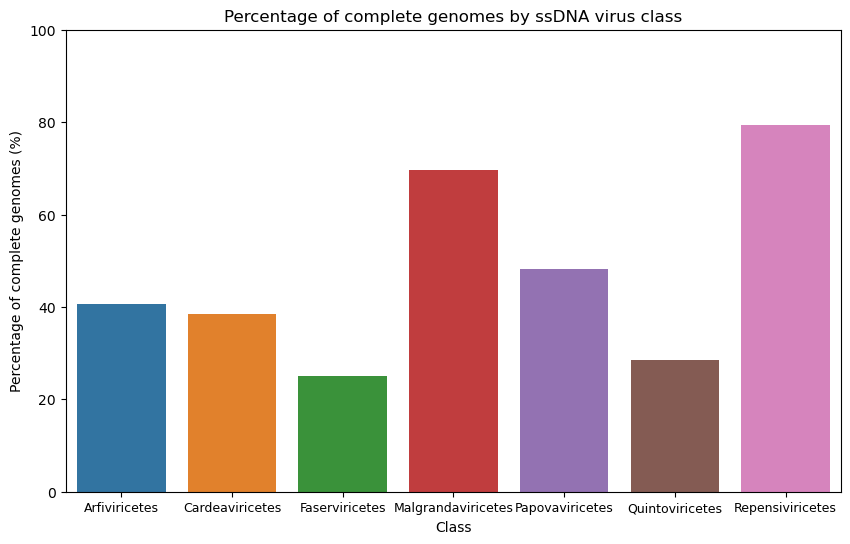

In [55]:
### create barplot of the % of complete genomes by class
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

comp_df = pd.DataFrame({
    'Class': ['Arfiviricetes', 'Cardeaviricetes', 'Faserviricetes', 'Malgrandaviricetes', 'Papovaviricetes', 'Quintoviricetes', 'Repensiviricetes'],
    'Percent_Complete': [
        ssdna_viruses
            .filter(pl.col('checkv_quality') == 'Complete')
            .filter(pl.col('ictv_class') == 'Arfiviricetes').height * 100 / 
        ssdna_viruses
            .filter(pl.col('ictv_class') == 'Arfiviricetes').height,
        ssdna_viruses
            .filter(pl.col('checkv_quality') == 'Complete')
            .filter(pl.col('ictv_class') == 'Cardeaviricetes').height * 100 / 
        ssdna_viruses
            .filter(pl.col('ictv_class') == 'Cardeaviricetes').height,
        ssdna_viruses
            .filter(pl.col('checkv_quality') == 'Complete')
            .filter(pl.col('ictv_class') == 'Faserviricetes').height * 100 / 
        ssdna_viruses
            .filter(pl.col('ictv_class') == 'Faserviricetes').height,
        ssdna_viruses
            .filter(pl.col('checkv_quality') == 'Complete')
            .filter(pl.col('ictv_class') == 'Malgrandaviricetes').height * 100 / 
        ssdna_viruses
            .filter(pl.col('ictv_class') == 'Malgrandaviricetes').height,
        ssdna_viruses
            .filter(pl.col('checkv_quality') == 'Complete')
            .filter(pl.col('ictv_class') == 'Papovaviricetes').height * 100 / 
        ssdna_viruses
            .filter(pl.col('ictv_class') == 'Papovaviricetes').height,
        ssdna_viruses
            .filter(pl.col('checkv_quality') == 'Complete')
            .filter(pl.col('ictv_class') == 'Quintoviricetes').height * 100 / 
        ssdna_viruses
            .filter(pl.col('ictv_class') == 'Quintoviricetes').height,
        ssdna_viruses
            .filter(pl.col('checkv_quality') == 'Complete')
            .filter(pl.col('ictv_class') == 'Repensiviricetes').height * 100 / 
        ssdna_viruses
            .filter(pl.col('ictv_class') == 'Repensiviricetes').height,
        
    ]
})
plt.figure(figsize=(10,6))
sns.barplot(x='Class', y='Percent_Complete', data=comp_df, hue='Class')
plt.ylabel('Percentage of complete genomes (%)')
plt.title('Percentage of complete genomes by ssDNA virus class')
plt.ylim(0, 100)
# decrease x-axis label text size
plt.xticks(fontsize=9)
plt.show()

In [56]:
votu_info = pl.read_csv('../../figure_2/vclust/uhvdb_vclust_cluster_info_final.tsv', separator='\t').rename({'contig_id':'seq_name'})[['seq_name', 'length', 'num_seqs']]
ssdna_viruses = ssdna_viruses.join(votu_info, on='seq_name', how='inner')

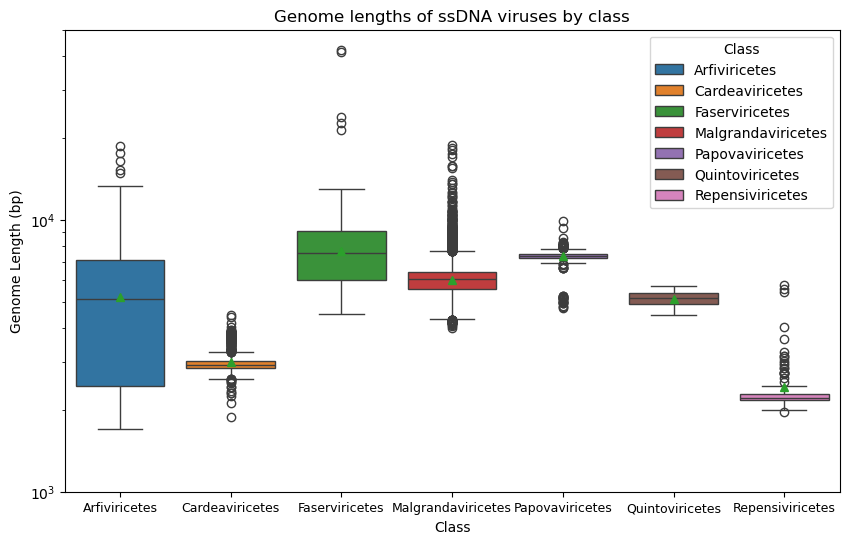

In [57]:
# create a boxplot of the lengths of ssDNA viruses by class
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

length_df = pd.DataFrame({
    'Length': ssdna_viruses.sort('ictv_class')['length'].to_list(),
    'Class': ssdna_viruses.sort('ictv_class')['ictv_class'].to_list()
})
plt.figure(figsize=(10,6))
sns.boxplot(x='Class', y='Length', data=length_df, hue='Class', showmeans=True)
plt.ylabel('Genome Length (bp)')
plt.yscale('log')
plt.ylim(1000, 50000)
plt.title('Genome lengths of ssDNA viruses by class')
# decrease x-axis label text size
plt.xticks(fontsize=9)
plt.show()

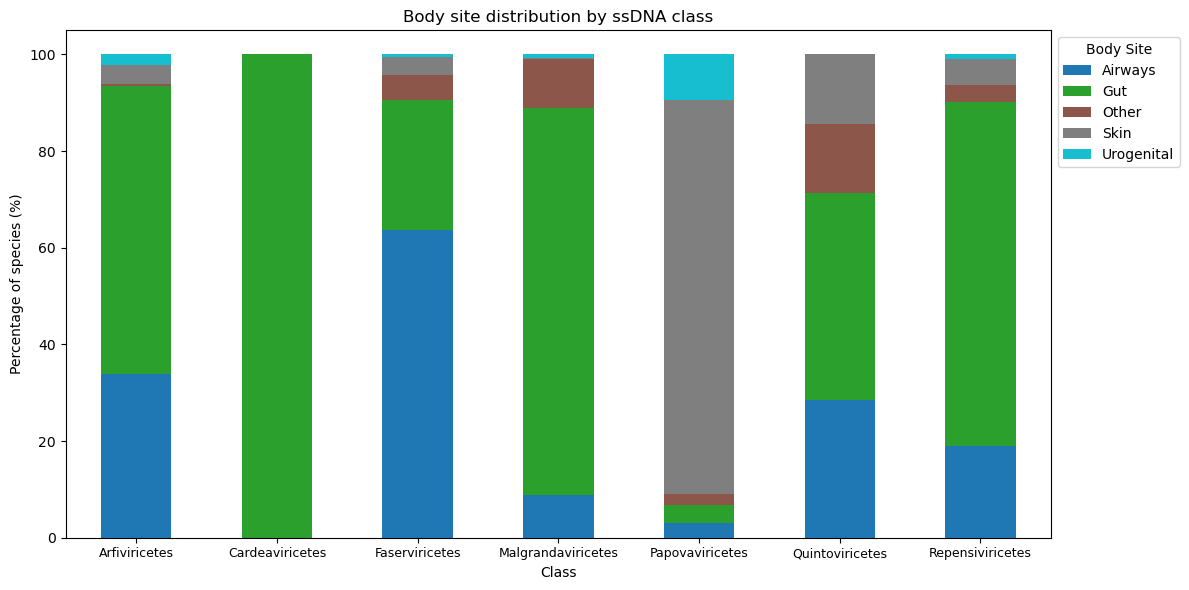

In [58]:
# create stacked barplot of the proportion from each body site by class
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get counts of each class-body site combination
body_site_data = (
    ssdna_viruses
    .group_by(['ictv_class', 'body_site'])
    .agg(pl.count('seq_name').alias('count'))
    .filter(pl.col('ictv_class').is_not_null())
    .to_pandas()
)

# Pivot to get body sites as columns
pivot_df = body_site_data.pivot(index='ictv_class', columns='body_site', values='count').fillna(0)

# Calculate proportions (normalize by row)
pivot_prop = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Create stacked barplot
ax = pivot_prop.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.xlabel('Class')
plt.ylabel('Percentage of species (%)')
plt.title('Body site distribution by ssDNA class')
plt.legend(title='Body Site', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

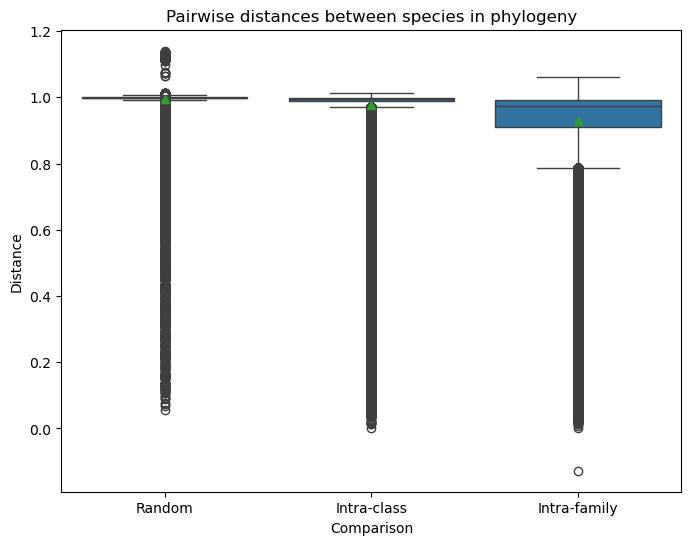

In [59]:
### create boxplot of distances for random vs intra-family
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dist_df = pd.DataFrame({
    'Distance': dist_1k_lst + intra_class_dist + intra_family_dist,
    'Comparison': ['Random'] * len(dist_1k_lst) + ['Intra-class'] * len(intra_class_dist) + ['Intra-family'] * len(intra_family_dist)
})
plt.figure(figsize=(8,6))
sns.boxplot(x='Comparison', y='Distance', data=dist_df, showmeans=True)
plt.title('Pairwise distances between species in phylogeny')
plt.show()

In [ ]:
votu_info = pl.read_csv('../../figure_2/vclust/uhvdb_vclust_cluster_info_final.tsv', separator='\t').rename({'contig_id':'seq_name'})[['seq_name', 'length', 'num_seqs']]
ssdna_viruses = pl.read_csv('../ssdna_annotations/all_ssdna_annotations.tsv', separator='\t').join(votu_info, on='seq_name', how='inner')
dsdna_viruses = pl.read_csv('../dsdna_annotations/all_dsdna_annotations.tsv', separator='\t').join(votu_info, on='seq_name', how='inner')
print("Average length ssDNA viruses:", ssdna_viruses['length'].mean())
print("Average length dsDNA viruses:", dsdna_viruses['length'].mean())

Average length ssDNA viruses: 6148.540480102227
Average length dsDNA viruses: 50972.43544474546


In [67]:
# proportion ssdna non-gut vs dsdna non-gut
print("Prop ssdna that are non-gut:",
    ssdna_viruses
        .filter(pl.col('body_site') != 'Gut').height / 
    ssdna_viruses.height
)
print("Prop dsdna that are non-gut:",
    dsdna_viruses
        .filter(pl.col('body_site') != 'Gut').height / 
    dsdna_viruses.height
)

Prop ssdna that are non-gut: 0.2997444322745528
Prop dsdna that are non-gut: 0.5742583797141205
